In [2]:
#connect to drive because the dataset is there in drive

from google.colab import drive
drive.mount('/content/drive')  # mount -> Attach my Google Drive here so I can access my files


Mounted at /content/drive


In [3]:
# unzip the zip file

!unzip '/content/drive/MyDrive/Deep Learning/Computer_Vision/Binary_CNN_DOG_VS_CAT/archive.zip' -d '/content/dataset_dogs_cats'


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4419.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.442.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4420.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4421.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4422.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4424.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4425.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4426.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4427.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4431.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4433.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4436.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4438.jpg  
  inflating: /content/dataset_dogs_cats/train/dogs/dog.4439.jpg  
  inflating: /content/data

In [4]:
!ls

dataset_dogs_cats  drive  sample_data


In [5]:
%cd 'dataset_dogs_cats'

/content/dataset_dogs_cats


In [6]:
!ls

train  val


In [7]:
data_set = "/content/dataset_dogs_cats"

training_data_path = "/content/dataset_dogs_cats/train"
val_data_path = "/content/dataset_dogs_cats/val"

In [8]:
import os

print(len(os.listdir(data_set+"/train/cats")))
print(len(os.listdir(data_set+"/train/dogs")))

10000
10000


In [9]:
print(len(os.listdir(data_set+"/val/cats")))
print(len(os.listdir(data_set+"/val/dogs")))

2500
2500


In [10]:
os.listdir(training_data_path+"/cats")

['cat.58.jpg',
 'cat.2714.jpg',
 'cat.1715.jpg',
 'cat.6981.jpg',
 'cat.10620.jpg',
 'cat.2432.jpg',
 'cat.11893.jpg',
 'cat.11433.jpg',
 'cat.9858.jpg',
 'cat.5375.jpg',
 'cat.5226.jpg',
 'cat.554.jpg',
 'cat.9599.jpg',
 'cat.882.jpg',
 'cat.10004.jpg',
 'cat.12304.jpg',
 'cat.7538.jpg',
 'cat.7104.jpg',
 'cat.11292.jpg',
 'cat.2648.jpg',
 'cat.2252.jpg',
 'cat.4864.jpg',
 'cat.6166.jpg',
 'cat.6370.jpg',
 'cat.7166.jpg',
 'cat.4658.jpg',
 'cat.6673.jpg',
 'cat.8813.jpg',
 'cat.604.jpg',
 'cat.9789.jpg',
 'cat.11904.jpg',
 'cat.7648.jpg',
 'cat.5998.jpg',
 'cat.3020.jpg',
 'cat.12305.jpg',
 'cat.1830.jpg',
 'cat.7598.jpg',
 'cat.8965.jpg',
 'cat.1680.jpg',
 'cat.3742.jpg',
 'cat.8253.jpg',
 'cat.2.jpg',
 'cat.2905.jpg',
 'cat.999.jpg',
 'cat.6803.jpg',
 'cat.532.jpg',
 'cat.8267.jpg',
 'cat.8600.jpg',
 'cat.4782.jpg',
 'cat.2552.jpg',
 'cat.5972.jpg',
 'cat.7828.jpg',
 'cat.7496.jpg',
 'cat.852.jpg',
 'cat.11171.jpg',
 'cat.2775.jpg',
 'cat.209.jpg',
 'cat.12321.jpg',
 'cat.3644.jpg',

In [11]:
os.listdir(training_data_path+"/dogs")

['dog.6345.jpg',
 'dog.4589.jpg',
 'dog.8163.jpg',
 'dog.8769.jpg',
 'dog.1068.jpg',
 'dog.4096.jpg',
 'dog.2200.jpg',
 'dog.4173.jpg',
 'dog.10368.jpg',
 'dog.7895.jpg',
 'dog.8833.jpg',
 'dog.7735.jpg',
 'dog.3580.jpg',
 'dog.2711.jpg',
 'dog.8640.jpg',
 'dog.2259.jpg',
 'dog.9390.jpg',
 'dog.4750.jpg',
 'dog.11658.jpg',
 'dog.1579.jpg',
 'dog.7921.jpg',
 'dog.6631.jpg',
 'dog.9441.jpg',
 'dog.8027.jpg',
 'dog.327.jpg',
 'dog.4953.jpg',
 'dog.4841.jpg',
 'dog.8085.jpg',
 'dog.6507.jpg',
 'dog.12271.jpg',
 'dog.10097.jpg',
 'dog.11222.jpg',
 'dog.11517.jpg',
 'dog.7550.jpg',
 'dog.2838.jpg',
 'dog.2842.jpg',
 'dog.1048.jpg',
 'dog.5078.jpg',
 'dog.5337.jpg',
 'dog.7255.jpg',
 'dog.3326.jpg',
 'dog.11602.jpg',
 'dog.4156.jpg',
 'dog.11703.jpg',
 'dog.5906.jpg',
 'dog.859.jpg',
 'dog.12319.jpg',
 'dog.11329.jpg',
 'dog.10589.jpg',
 'dog.12026.jpg',
 'dog.3400.jpg',
 'dog.10906.jpg',
 'dog.6567.jpg',
 'dog.5457.jpg',
 'dog.5411.jpg',
 'dog.12225.jpg',
 'dog.4261.jpg',
 'dog.9151.jpg',
 '

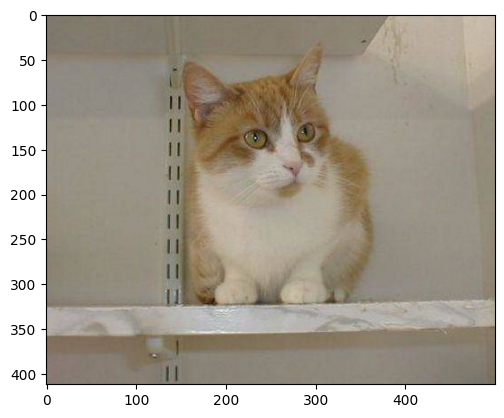

In [12]:
# reading the image in train of cat one image using matplotlib

import numpy as np
import matplotlib.pyplot as plt

cat_img = plt.imread(training_data_path+'/cats/cat.1943.jpg')

plt.imshow(cat_img)
plt.show()

In [13]:
# u should not give the image directly to architeture first give to ImageDataGenerator
# By ImageDataGenerator -> for image we apply some filps, rotations, scale down the pixel values between 0 and 1

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [14]:
# Define the Rules
training_data_preprocessing = ImageDataGenerator(1/255,
                                   rotation_range=0.2,
                                   shear_range=0.2,
                                   horizontal_flip=True)
validation_data_preprocessing = ImageDataGenerator(1/255,
                                   rotation_range=0.2,
                                   shear_range=0.2,
                                   horizontal_flip=True)


In [15]:
labels = ['cats', 'dogs']

In [16]:
# Applying the rules on training data and validation data

final_training_data = training_data_preprocessing.flow_from_directory(training_data_path,
                                                target_size=(200,200),
                                                classes=labels,
                                                class_mode='binary',
                                                batch_size=32)


final_valdiation_data = validation_data_preprocessing.flow_from_directory(val_data_path,
                                                target_size=(200,200),
                                                classes=labels,
                                                class_mode='binary',
                                                batch_size=32)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [17]:
# Architecture of Binary CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Activation
from tensorflow.keras.activations import relu, sigmoid


In [18]:
model = Sequential()

# Hidden Layer - 1 (applying filter and max pooling)
model.add(Conv2D(filters=500,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='valid',
                 kernel_initializer='he_uniform',
                 activation=relu))
model.add(MaxPool2D(pool_size=(2, 2)))

# Hidden Layer - 2
model.add(Conv2D(filters=250,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='valid',
                 kernel_initializer='he_uniform',
                 activation=relu))
model.add(MaxPool2D(pool_size=(2, 2)))

# Hidden Layer - 3
model.add(Conv2D(filters=100,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='valid',
                 kernel_initializer='he_uniform',
                 activation=relu))
model.add(MaxPool2D(pool_size=(2, 2)))

# Hidden Layer - 4
model.add(Conv2D(filters=50,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='valid',
                 kernel_initializer='he_uniform',
                 activation=relu))
model.add(MaxPool2D(pool_size=(2, 2)))

# Hidden Layer - 5
model.add(Conv2D(filters=20,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='valid',
                 kernel_initializer='he_uniform',
                 activation=relu))
model.add(MaxPool2D(pool_size=(2, 2)))

# Flatten

model.add(Flatten())

# now give to the ANN

# flatten to Hidden layer - 1
model.add(Dense(units=300, activation=relu, kernel_initializer='he_uniform'))

# Hidden Layer - 1 to Hidden Layer - 2
model.add(Dense(units=200, activation=relu, kernel_initializer='he_uniform'))

# Hidden Layer - 2 to Hidden Layer - 3
model.add(Dense(units=100, activation=relu, kernel_initializer='he_uniform'))

# Hidden Layer - 3 to Hidden Layer - 4
model.add(Dense(units=50, activation=relu, kernel_initializer='he_uniform'))

# Hidden Layer - 4 to Hidden Layer - 5
model.add(Dense(units=20, activation=relu, kernel_initializer='he_uniform'))

# Hidden Layer - 5 to Hidden Layer - 6
model.add(Dense(units=1, kernel_initializer='glorot_uniform', activation=sigmoid))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Accuracy'])

In [ ]:
model.fit(final_training_data, validation_data=final_valdiation_data, epochs=23)

In [ ]:
'''
Epoch 1/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 557s 827ms/step - Accuracy: 0.5142 - loss: 5.1262 - val_Accuracy: 0.5152 - val_loss: 0.6932
Epoch 2/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.5111 - loss: 0.6925 - val_Accuracy: 0.4990 - val_loss: 0.7073
Epoch 3/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.5049 - loss: 0.6915 - val_Accuracy: 0.5074 - val_loss: 0.6938
Epoch 4/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 500s 799ms/step - Accuracy: 0.5165 - loss: 0.6914 - val_Accuracy: 0.5006 - val_loss: 0.6923
Epoch 5/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 502s 800ms/step - Accuracy: 0.5084 - loss: 0.6919 - val_Accuracy: 0.5072 - val_loss: 0.6939
Epoch 6/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.5131 - loss: 0.6924 - val_Accuracy: 0.5160 - val_loss: 0.6904
Epoch 7/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 797ms/step - Accuracy: 0.5121 - loss: 0.6916 - val_Accuracy: 0.5112 - val_loss: 0.6945
Epoch 8/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 796ms/step - Accuracy: 0.5138 - loss: 0.6911 - val_Accuracy: 0.5084 - val_loss: 0.6958
Epoch 9/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.5059 - loss: 0.6959 - val_Accuracy: 0.5008 - val_loss: 0.6936
Epoch 10/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 504s 801ms/step - Accuracy: 0.4915 - loss: 0.6938 - val_Accuracy: 0.4996 - val_loss: 0.6931
Epoch 11/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.4999 - loss: 0.6944 - val_Accuracy: 0.5000 - val_loss: 0.6931
Epoch 12/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 797ms/step - Accuracy: 0.4940 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6931
Epoch 13/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 497s 795ms/step - Accuracy: 0.4992 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6933
Epoch 14/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 497s 795ms/step - Accuracy: 0.4974 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6933
Epoch 15/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 798ms/step - Accuracy: 0.5013 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6937
Epoch 16/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 797ms/step - Accuracy: 0.4978 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6931
Epoch 17/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 796ms/step - Accuracy: 0.5016 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6931
Epoch 18/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 508s 812ms/step - Accuracy: 0.4927 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6931
Epoch 19/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 500s 799ms/step - Accuracy: 0.4985 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 20/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 797ms/step - Accuracy: 0.4976 - loss: 0.6933 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 21/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 501s 795ms/step - Accuracy: 0.4973 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6933
Epoch 22/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 497s 794ms/step - Accuracy: 0.5065 - loss: 0.6931 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 23/23
625/625 ━━━━━━━━━━━━━━━━━━━━ 497s 794ms/step - Accuracy: 0.4998 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932

'''

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
dogs


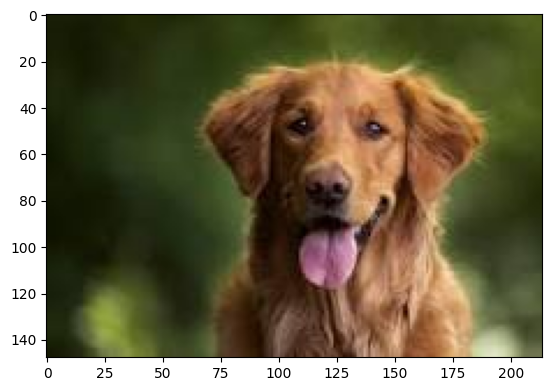

In [22]:
# do predictions

import cv2

def predict_cnn(path_of_image):
  image = cv2.imread(path_of_image)
  resized_image = cv2.resize(image,(200,200))
  scaled_pixel_value = resized_image/255
  input_image = np.expand_dims(scaled_pixel_value, axis = 0)
  result = model.predict(input_image)
  print(result)

  if result[0][0] > 0.5:
    print('cats')
  else:
    print('dogs')

  plt.imshow(image[:,:,::-1])
  plt.show()

predict_cnn('/content/dog.jpeg')

In [ ]:
predict_cnn('path')